In [31]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler, MinMaxScaler, RobustScaler

In [32]:
df = pd.read_csv("/content/hotel_bookings.csv")

In [33]:
df.shape

(119390, 32)

In [34]:
df.columns

Index(['hotel', 'is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_month', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies', 'meal',
       'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'deposit_type', 'agent',
       'company', 'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'reservation_status', 'reservation_status_date'],
      dtype='object')

In [35]:
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [36]:
df.tail()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
119385,City Hotel,0,23,2017,August,35,30,2,5,2,...,No Deposit,394.0,NaN,0,Transient,96.14,0,0,Check-Out,2017-09-06
119386,City Hotel,0,102,2017,August,35,31,2,5,3,...,No Deposit,9.0,NaN,0,Transient,225.43,0,2,Check-Out,2017-09-07
119387,City Hotel,0,34,2017,August,35,31,2,5,2,...,No Deposit,9.0,NaN,0,Transient,157.71,0,4,Check-Out,2017-09-07
119388,City Hotel,0,109,2017,August,35,31,2,5,2,...,No Deposit,89.0,NaN,0,Transient,104.40,0,0,Check-Out,2017-09-07
119389,City Hotel,0,205,2017,August,35,29,2,7,2,...,No Deposit,9.0,NaN,0,Transient,151.20,0,2,Check-Out,2017-09-07


In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [38]:
df.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119386.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,103050.000000,6797.000000,119390.000000,119390.000000,119390.000000,119390.000000
mean,0.370416,104.011416,2016.156554,27.165173,15.798241,0.927599,2.500302,1.856403,0.103890,0.007949,0.031912,0.087118,0.137097,0.221124,86.693382,189.266735,2.321149,101.831122,0.062518,0.571363
std,0.482918,106.863097,0.707476,13.605138,8.780829,0.998613,1.908286,0.579261,0.398561,0.097436,0.175767,0.844336,1.497437,0.652306,110.774548,131.655015,17.594721,50.535790,0.245291,0.792798
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,62.000000,0.000000,69.290000,0.000000,0.000000
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,179.000000,0.000000,94.575000,0.000000,0.000000
75%,1.000000,160.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,229.000000,270.000000,0.000000,126.000000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,543.000000,391.000000,5400.000000,8.000000,5.000000


In [39]:
df.isnull().sum()

,0
hotel,0
is_canceled,0
lead_time,0
arrival_date_year,0
arrival_date_month,0
arrival_date_week_number,0
arrival_date_day_of_month,0
stays_in_weekend_nights,0
stays_in_week_nights,0
adults,0


In [40]:
df.nunique()

,0
hotel,2
is_canceled,2
lead_time,479
arrival_date_year,3
arrival_date_month,12
arrival_date_week_number,53
arrival_date_day_of_month,31
stays_in_weekend_nights,17
stays_in_week_nights,35
adults,14


In [41]:
df["children"] = df["children"].fillna(0).astype(int)

In [42]:
df["country"] = df["country"].fillna(df["country"].mode()[0])

In [43]:
df["agent"] = df["agent"].fillna(0).astype(int)

In [44]:
df = df.drop(columns='company')

In [45]:
df.isnull().sum()

,0
hotel,0
is_canceled,0
lead_time,0
arrival_date_year,0
arrival_date_month,0
arrival_date_week_number,0
arrival_date_day_of_month,0
stays_in_weekend_nights,0
stays_in_week_nights,0
adults,0


In [46]:
df.duplicated().sum()

np.int64(32020)

In [47]:
df = df.drop_duplicates()

In [48]:
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')

In [49]:
df = df.drop(columns=["reservation_status", "reservation_status_date"]) # reservation_status directly reveals is_canceled, and reservation_status_date is only known after the booking outcome

 SUMMARY:

 is_canceled: Used as the target variable to identify whether a booking was canceled or not.

lead_time: Used to analyze whether the time between booking and arrival influences cancellation behavior.

adr: Used to understand how the average daily room price differs between booking outcomes.

stays_in_week_nights: Used to analyze whether the number of weekday nights affects booking and cancellation patterns.

days_in_waiting_list: Used to understand whether waiting time for confirmation is related to cancellations.

booking_changes: Used to examine whether frequent reservation modifications are associated with cancellation behavior.

previous_cancellations: Used to determine whether a customer's past cancellations influence future cancellations.

hotel: Used to compare booking and cancellation patterns between different hotel types.

deposit_type: Used to analyze whether different deposit requirements influence cancellation behavior.

market_segment: Used to understand cancellation patterns across different booking and customer acquisition segments.

customer_type: Used to compare booking and cancellation behavior among different types of customers.

total_of_special_requests: Used to examine whether customers making more special requests show different cancellation patterns.

stays_in_weekend_nights: Used to analyze whether weekend stay duration affects booking behavior and identify unusual values.

children: Used to understand whether the presence or number of children influences booking patterns.

country: Used to analyze booking behavior based on the customer's country of origin.

agent: Used to understand how bookings and cancellation patterns vary across booking agents.

company: Dropped because it contains a very high number of missing values, making it less reliable for analysis and model training.

reservation_status: Dropped because it directly reflects the final booking outcome and can cause target leakage.

reservation_status_date: Dropped because it is closely related to the final reservation outcome and can cause target leakage.


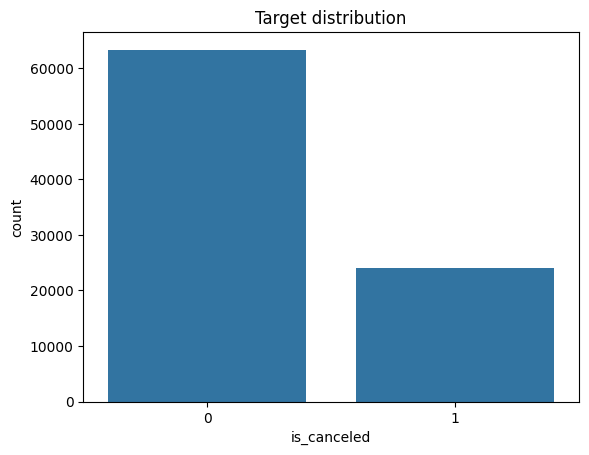

In [50]:
sns.countplot(x="is_canceled", data=df)
plt.title("Target distribution")
plt.show()

Is Canceled: Shows the number of canceled and non-canceled bookings and helps understand the target distribution for the analysis.

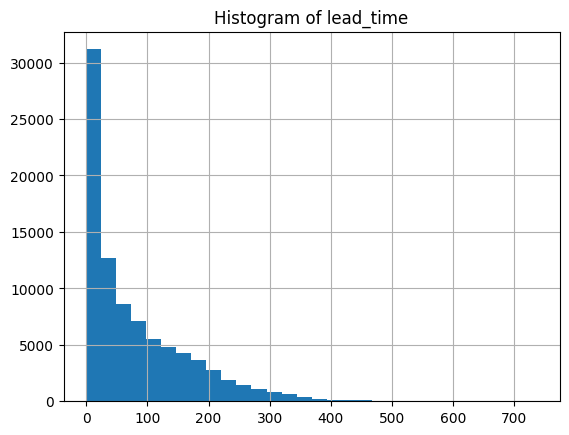

Skewness of lead_time: 1.4315


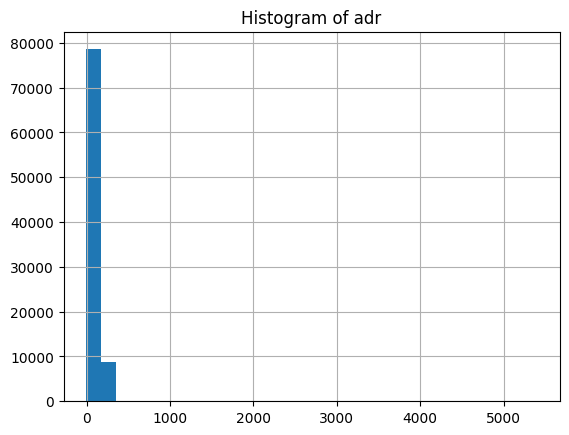

Skewness of adr: 10.9294


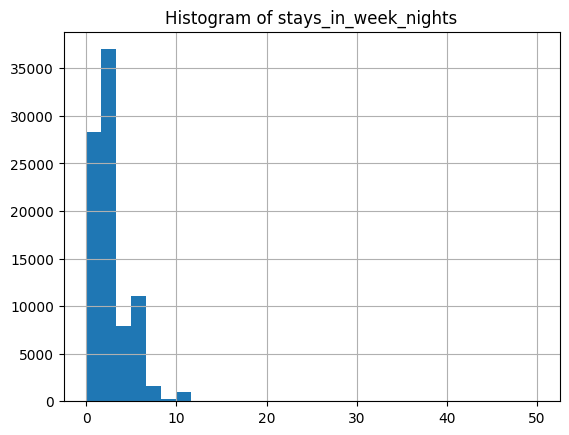

Skewness of stays_in_week_nights: 2.6913


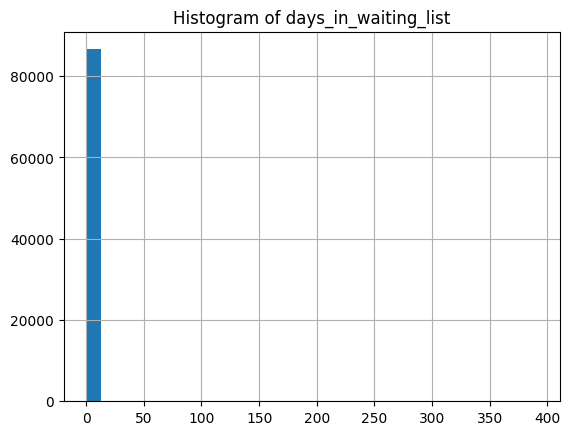

Skewness of days_in_waiting_list: 19.3935


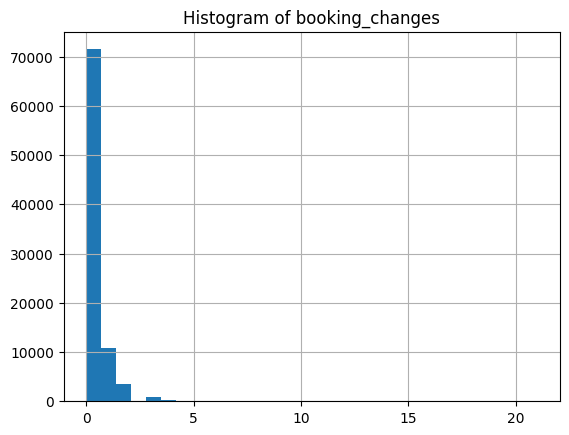

Skewness of booking_changes: 5.5456


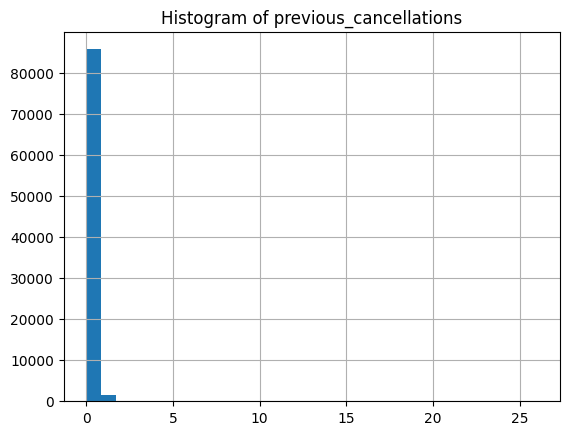

Skewness of previous_cancellations: 34.3187


In [51]:
num_cols = ["lead_time", "adr", "stays_in_week_nights", "days_in_waiting_list", "booking_changes", "previous_cancellations"]

for col in num_cols:
    df[col].hist(bins=30)
    plt.title(f"Histogram of {col}")
    plt.show()
    print(f"Skewness of {col}: {df[col].skew():.4f}")

Lead Time: Shows how far in advance customers make bookings and helps identify common booking patterns and skewness.

ADR: Shows the distribution of average daily room rates and helps understand pricing patterns and extreme values.

Stays in Week Nights: Shows the distribution of weekday stay duration and helps understand typical length of stay.

Days in Waiting List: Shows how long bookings remain on the waiting list and helps identify whether waiting times are concentrated or highly skewed.

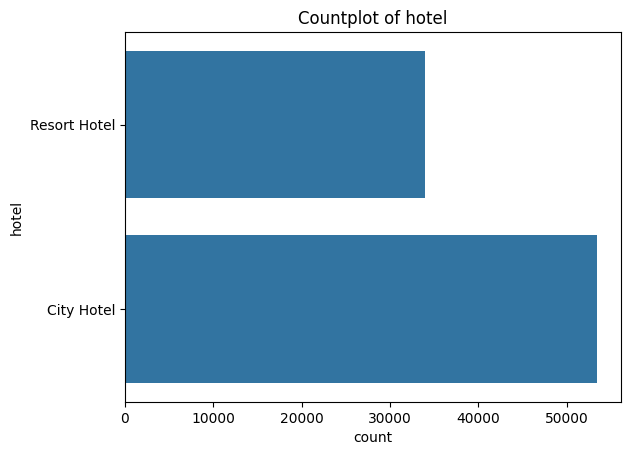

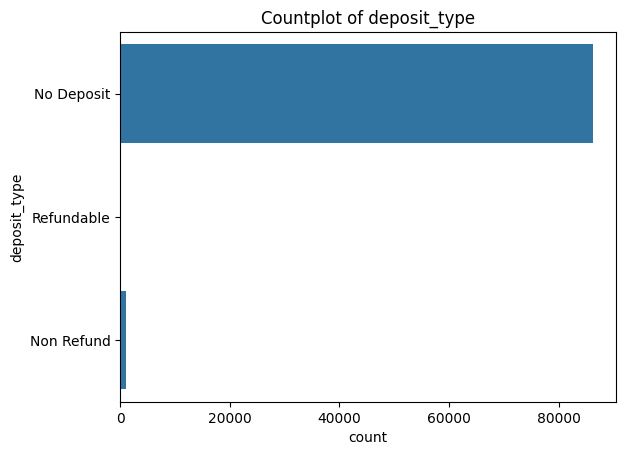

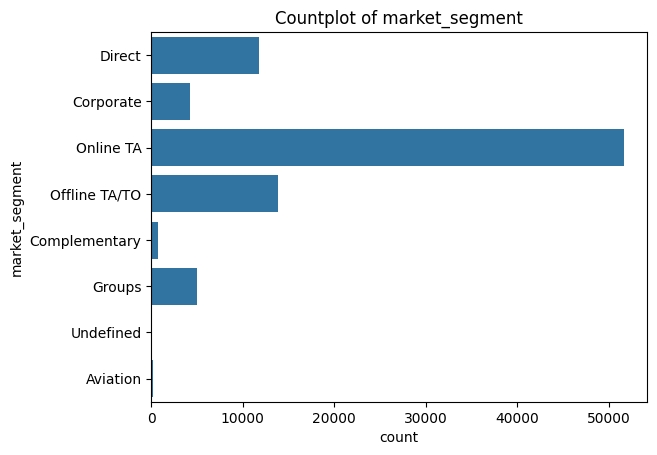

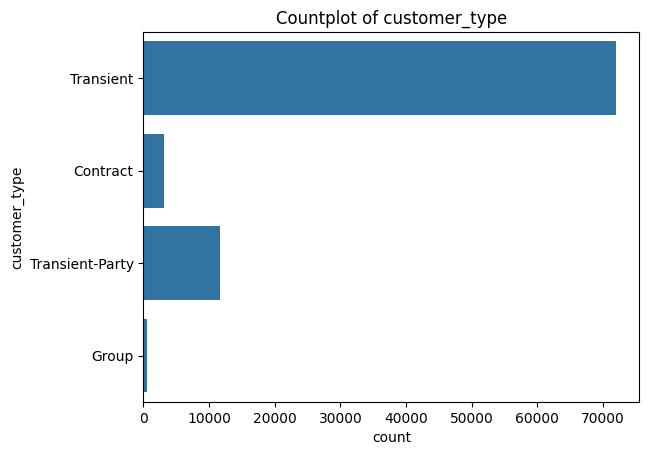

In [52]:
cat_cols = ["hotel", "deposit_type", "market_segment", "customer_type"]

for col in cat_cols:
    sns.countplot(y=col, data=df)
    plt.title(f"Countplot of {col}")
    plt.show()

Hotel: Shows the number of bookings for each hotel type and helps compare booking demand between hotels.

Deposit Type: Shows how many bookings fall under each deposit category and helps understand the relationship between deposit requirements and cancellations.

Market Segment: Shows booking volume across different market segments and helps identify the major sources of hotel bookings.

Customer Type: Shows the distribution of different customer types and helps understand which customer groups contribute most to bookings.

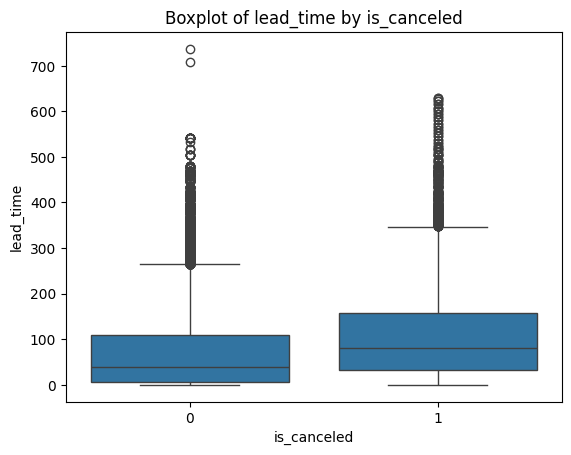

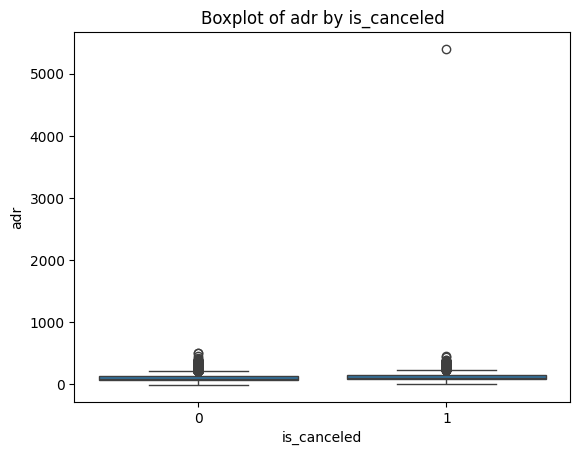

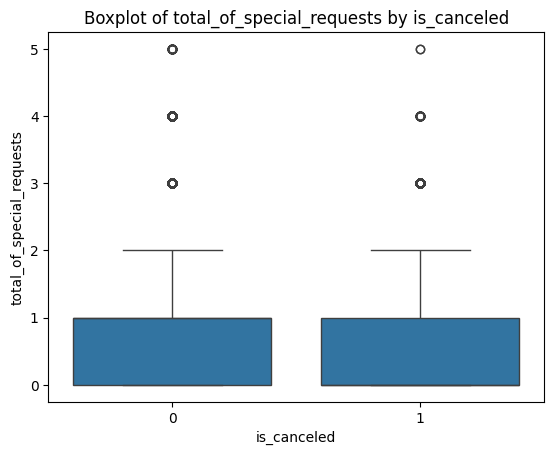

In [53]:
cols = ["lead_time", "adr", "total_of_special_requests"]

for col in cols:
    sns.boxplot(x="is_canceled", y=col, data=df)
    plt.title(f"Boxplot of {col} by is_canceled")
    plt.show()

Lead Time vs Is Canceled: Compares lead-time distributions between canceled and non-canceled bookings to identify differences in advance booking behavior.

ADR vs Is Canceled: Compares room rates between canceled and non-canceled bookings to identify pricing-related differences.

Total Special Requests vs Is Canceled: Compares customer requests across booking outcomes to understand whether special requests are associated with cancellations.

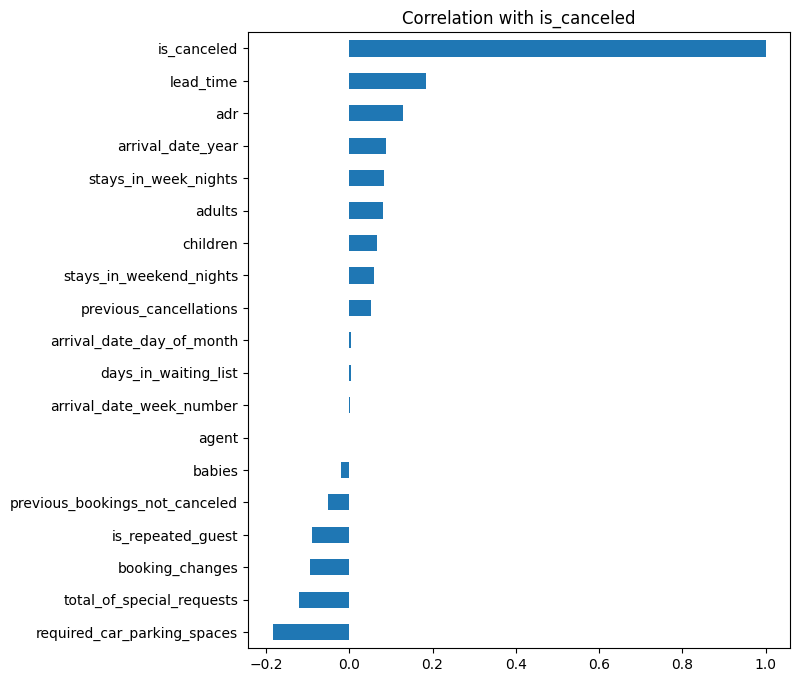

In [54]:
df.corr(numeric_only=True)["is_canceled"].sort_values().plot(kind="barh", figsize=(7, 8))
plt.title("Correlation with is_canceled")
plt.show()

Correlation with Is Canceled: Measures the strength and direction of relationships between numerical features and cancellation, helping identify potentially important variables.

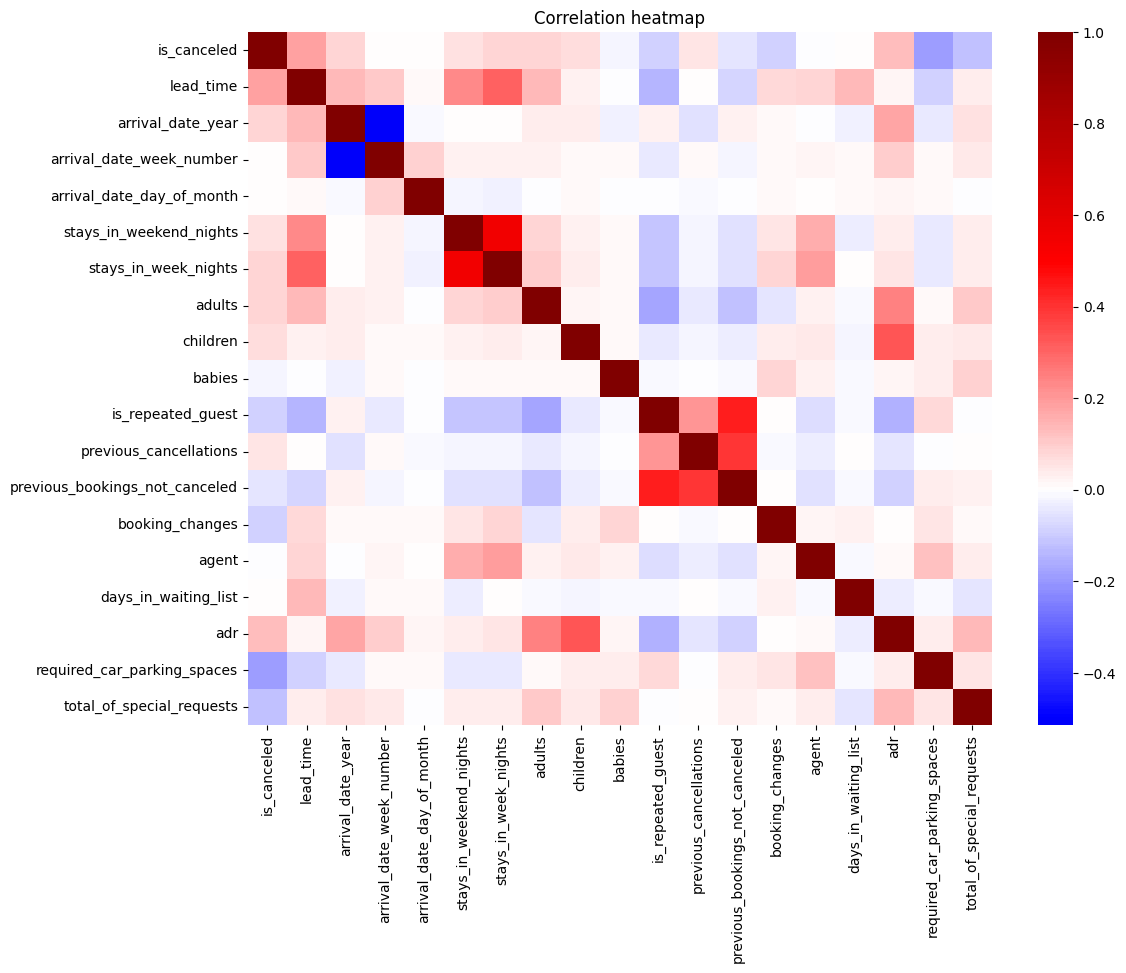

In [55]:
plt.figure(figsize=(12, 9))
sns.heatmap(df.corr(numeric_only=True), center=0, cmap="seismic")
plt.title("Correlation heatmap")
plt.show()

Correlation Heatmap: Displays correlations among numerical variables and helps identify strong relationships and possible multicollinearity.

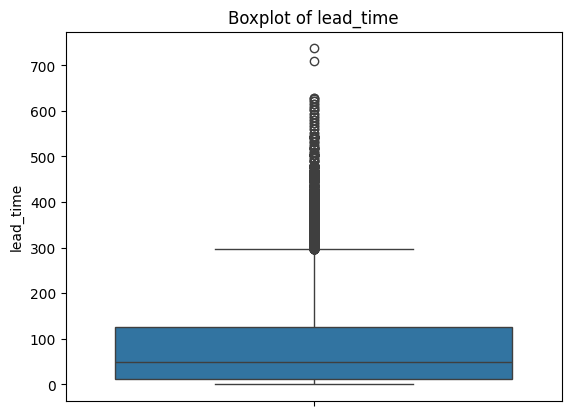

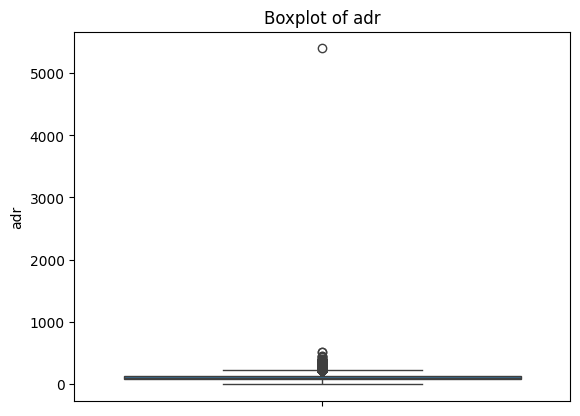

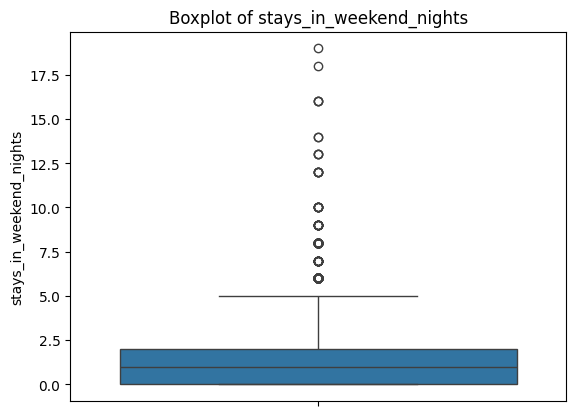

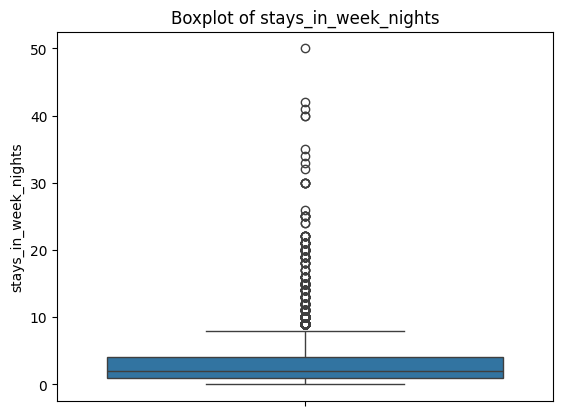

In [56]:
out_cols = ["lead_time", "adr", "stays_in_weekend_nights", "stays_in_week_nights"]

for col in out_cols:
    sns.boxplot(y=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

Lead Time: Used to identify unusually high advance-booking periods that could influence the analysis.

ADR: Used to detect unusually high or low room rates that may distort statistical analysis or model performance.

Stays in Weekend Nights: Used to identify unusual weekend stay durations and potential extreme observations.

Stays in Week Nights: Used to identify unusually long or short weekday stays and assess their impact on the dataset.

In [57]:
for col in out_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    print(col, "-> outliers:", ((df[col] < lower) | (df[col] > upper)).sum())
    df[col] = df[col].clip(lower, upper)

lead_time -> outliers: 2396
adr -> outliers: 2488
stays_in_weekend_nights -> outliers: 220
stays_in_week_nights -> outliers: 1531


In [58]:

le = OneHotEncoder()

for col in df.select_dtypes(exclude="number").columns:
    # .toarray() converts the sparse matrix, and .ravel() flattens it back to a 1D column
    df[col] = le.fit_transform(df[[col]]).toarray()[:, 0]
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests
0,0.0,0,296,2015,0.0,27,1,0,0.0,2,...,0.0,0.0,3,1.0,0,0,0.0,0.0,0,0
1,0.0,0,296,2015,0.0,27,1,0,0.0,2,...,0.0,0.0,4,1.0,0,0,0.0,0.0,0,0
2,0.0,0,7,2015,0.0,27,1,0,1.0,1,...,1.0,0.0,0,1.0,0,0,0.0,75.0,0,0
3,0.0,0,13,2015,0.0,27,1,0,1.0,1,...,1.0,1.0,0,1.0,304,0,0.0,75.0,0,0
4,0.0,0,14,2015,0.0,27,1,0,2.0,2,...,1.0,1.0,0,1.0,240,0,0.0,98.0,0,1


Categorical variables were converted into numerical form using One-Hot Encoding so that machine-learning algorithms could process categorical information. This transforms categories into numerical features while avoiding the assumption that one category is greater or smaller than another.

In [59]:
X = df.drop(columns="is_canceled")
y = df["is_canceled"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Train:", X_train.shape, "| Test:", X_test.shape)

Train: (69896, 28) | Test: (17474, 28)


The dataset was divided into 80% training data and 20% testing data using train_test_split. Stratification was used to maintain a similar distribution of the target variable, is_canceled, in both the training and testing datasets.

In [60]:
std = StandardScaler()
X_train_std = std.fit_transform(X_train)
X_test_std = std.transform(X_test)

minmax = MinMaxScaler()
X_train_minmax = minmax.fit_transform(X_train)
X_test_minmax = minmax.transform(X_test)

robust = RobustScaler()
X_train_robust = robust.fit_transform(X_train)
X_test_robust = robust.transform(X_test)

print("Standard:", X_train_std.shape, "| MinMax:", X_train_minmax.shape, "| Robust:", X_train_robust.shape)

Standard: (69896, 28) | MinMax: (69896, 28) | Robust: (69896, 28)


Scaling was performed using StandardScaler, MinMaxScaler, and RobustScaler to bring numerical features into suitable ranges. StandardScaler standardizes values around the mean, MinMaxScaler scales values to a fixed range, and RobustScaler is less sensitive to extreme values and outliers.

In [61]:
from google.colab import files
df.to_csv('/content/cleaned_hotel_booking.csv', index=False)
files.download('/content/cleaned_hotel_booking.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>